# KNN:

## The KNN algorithm stores the entire training dataset as a referenace
## When making predictions , It calculates the distance between the input data point and all the trainign 
## Example: using a chosen distance metric such as Eclidean distance

# d(p,q)2 = (q1-p1)^2 + (q2-p2)^2

# underroot((x2-x1)^2 + (y2-y1)^2))

# The algorithm identifies the K neighbours to the input data points basesd on their distance
# In the case of classification , TBHe algorithm assigns the most common class label among the K neightbours at the predicred label for the input data points
# For regression, it calculates the averages of the targeet values of the K neighbours to predict the value for the input data points

In [2]:
import pandas as pd
import seaborn as sns

In [4]:
df = pd.read_csv("student1.csv")

In [5]:
df.head(10)

,name,gmat,gpa,exp,admitted,country
0,samir,780,4.0,3,1,Ind
1,kaushal,750,3.9,4,1,Ind
2,nandan,690,3.3,3,0,Ind
3,ankit,710,3.7,5,1,us
4,deepika,680,3.9,4,0,Ind
5,kshama,730,3.7,6,1,Ind
6,gaurav,690,2.3,1,0,us
7,john,720,3.3,4,1,us
8,nida,740,3.3,5,1,Ind
9,samir,690,1.7,1,0,Ind


In [6]:
df = df.drop(["name","country"],axis=1)

In [7]:
df.head()

,gmat,gpa,exp,admitted
0,780,4.0,3,1
1,750,3.9,4,1
2,690,3.3,3,0
3,710,3.7,5,1
4,680,3.9,4,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   gmat      42 non-null     int64  
 1   gpa       42 non-null     float64
 2   exp       42 non-null     int64  
 3   admitted  42 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 1.4 KB


In [9]:
df.describe()

,gmat,gpa,exp,admitted
count,42.000000,42.000000,42.000000,42.000000
mean,653.333333,3.123810,4.023810,0.500000
std,64.113720,0.629289,3.591916,0.506061
min,510.000000,1.700000,1.000000,0.000000
25%,602.500000,2.700000,2.000000,0.000000
50%,660.000000,3.300000,4.000000,0.500000
75%,690.000000,3.700000,5.000000,1.000000
max,780.000000,4.000000,24.000000,1.000000


In [10]:
df.isnull().sum()

gmat        0
gpa         0
exp         0
admitted    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(4)

In [12]:
df.shape

(42, 4)

In [14]:
df.drop_duplicates(inplace=True)

In [16]:
df.shape

(38, 4)

<Axes: >

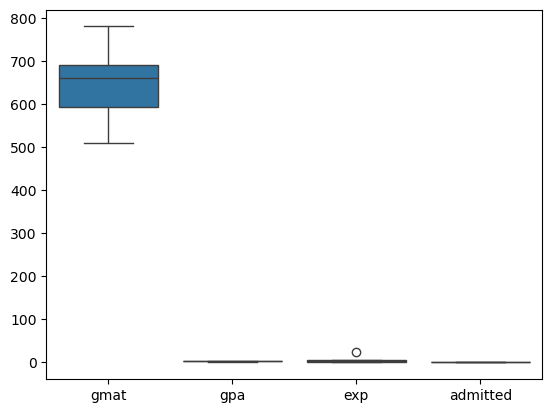

In [17]:
sns.boxplot(data=df)

In [18]:
df.describe()

,gmat,gpa,exp,admitted
count,38.000000,38.000000,38.000000,38.000000
mean,650.526316,3.063158,3.894737,0.447368
std,66.614963,0.631780,3.754561,0.503897
min,510.000000,1.700000,1.000000,0.000000
25%,592.500000,2.700000,2.000000,0.000000
50%,660.000000,3.300000,4.000000,0.000000
75%,690.000000,3.600000,5.000000,1.000000
max,780.000000,4.000000,24.000000,1.000000


In [19]:
q1 = 2.00
q3 = 5.00

iqr = q3 - q1

In [20]:
ub= q3 + (1.5*iqr)
lb= q1 - (1.5*iqr)

In [21]:
df = df[(df["exp"]>=lb)&(df["exp"]<=ub)]

<Axes: >

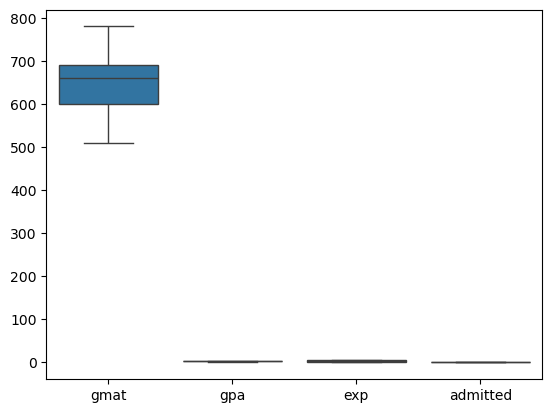

In [22]:
sns.boxplot(data=df)

In [25]:
x = df.drop("admitted",axis = 1)

In [24]:
y = df.admitted

In [26]:
from sklearn.model_selection import train_test_split

In [31]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)

In [32]:
x_train.shape,y_train.shape

((29, 3), (29,))

In [33]:
x_test.shape,y_test.shape

((8, 3), (8,))

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
model = LogisticRegression()

In [36]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
model.score(x_train,y_train),model.score(x_test,y_test)

(0.9310344827586207, 0.75)

In [41]:
ypred = model.predict(x_test)

In [42]:
ypred

array([1, 1, 1, 0, 0, 1, 0, 0])

In [43]:
from sklearn.metrics import confusion_matrix

In [44]:
cm = confusion_matrix(y_test,ypred)

In [45]:
cm

array([[4, 2],
       [0, 2]])

<Axes: >

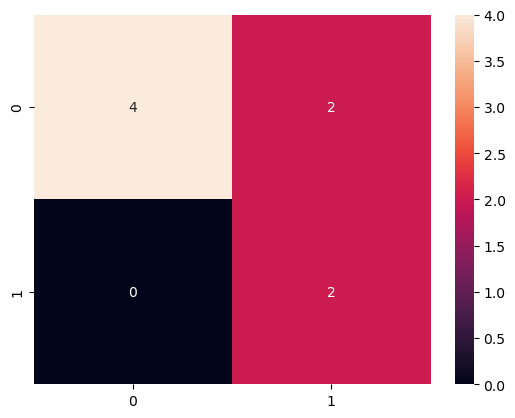

In [46]:
sns.heatmap(cm,annot=True)

In [49]:
from sklearn.neighbors import KNeighborsClassifier


In [51]:
model1 = KNeighborsClassifier(n_neighbors=3)

In [52]:
model1.fit(x_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [53]:
model1.score(x_train,y_train),model1.score(x_test,y_test)

(0.896551724137931, 0.75)

In [54]:
ypred2 = model1.predict(x_test)

In [55]:
ypred2

array([1, 1, 1, 0, 0, 1, 0, 0])

In [57]:
cm2 = confusion_matrix(y_test,ypred2)

<Axes: >

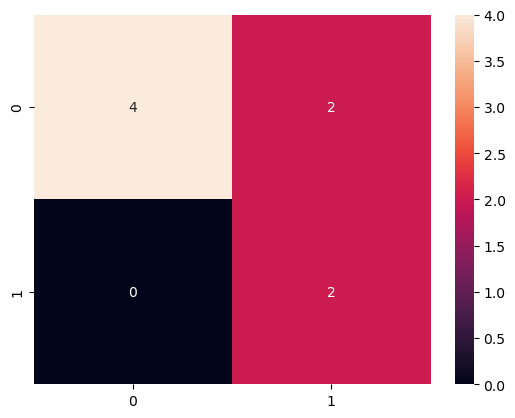

In [58]:
sns.heatmap(cm,annot=True)

In [59]:
from sklearn.metrics import classification_report

In [60]:
print("LogisticRegression: ",classification_report(y_test,ypred))

LogisticRegression:                precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       0.50      1.00      0.67         2

    accuracy                           0.75         8
   macro avg       0.75      0.83      0.73         8
weighted avg       0.88      0.75      0.77         8



In [61]:
print("KNN: ",classification_report(y_test,ypred2))

KNN:                precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       0.50      1.00      0.67         2

    accuracy                           0.75         8
   macro avg       0.75      0.83      0.73         8
weighted avg       0.88      0.75      0.77         8



In [63]:
trains = []
tests = []

for i in range(3,15):
    model1 = KNeighborsClassifier(n_neighbors=i)
    model1.fit(x_train,y_train)
    trains.append(model1.score(x_train,y_train))
    tests.append(model1.score(x_test,y_test))
    

In [64]:
import matplotlib.pyplot as plt

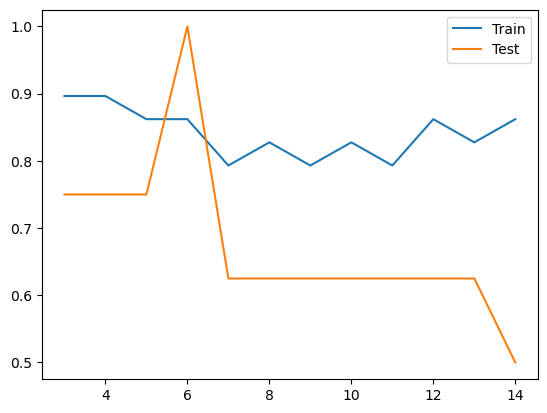

In [65]:
plt.plot(range(3,15),trains,label="Train")
plt.plot(range(3,15),tests,label="Test")
plt.legend()
plt.show()